# Comparing Results from 4 Regression Models
### ElasticNet, Support Vector Regression, Partial Least Squares Regression, HistGradientBoosting Regressor

In [ ]:
# Importing and loading results
import sys, os
sys.path.insert(0, '../src')
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport
import joblib, os
import preprocess
import explore
import model
os.environ['PYTHONWARNINGS'] = 'ignore'
MODEL_DIR = os.path.abspath('../models/pain-reduction')

# Performance Metrics against Selected Features
### From Feature Frequency Lists

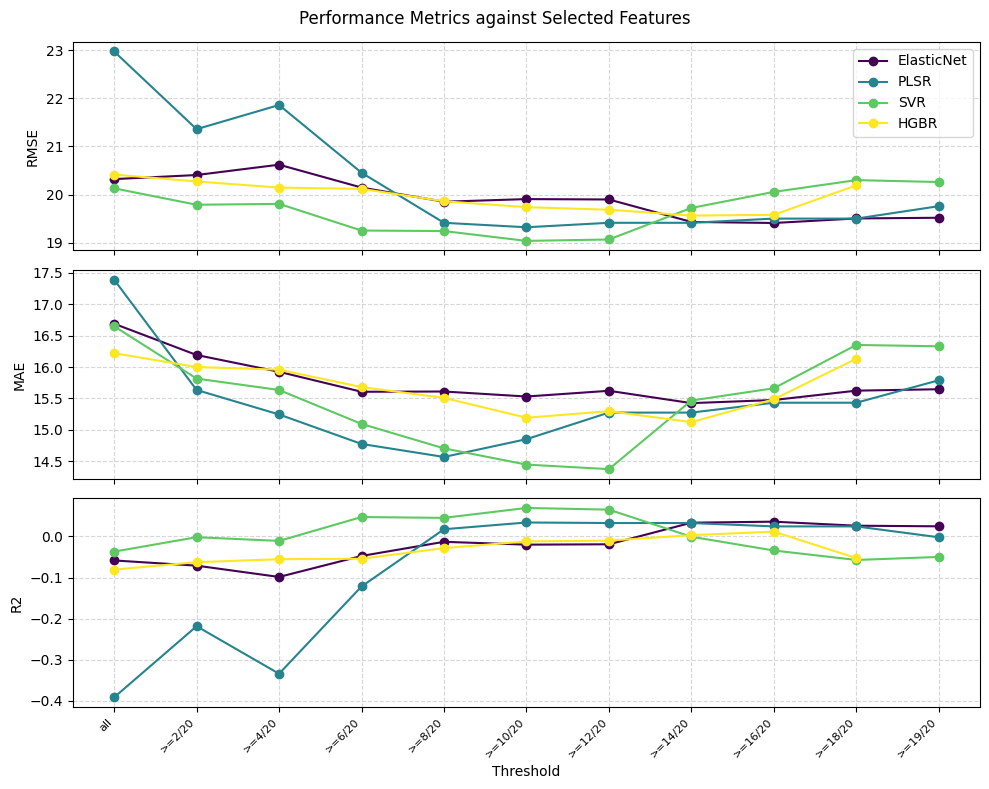

In [8]:
en_sweep = joblib.load(os.path.join(MODEL_DIR, 'en_ul_sweep_df.pkl'))
svr_sweep = joblib.load(os.path.join(MODEL_DIR, 'svr_sweep_df.pkl'))
pls_sweep = joblib.load(os.path.join(MODEL_DIR, 'pls_sweep_df.pkl'))
hgbr_sweep = joblib.load(os.path.join(MODEL_DIR, 'hgbr_sweep_df.pkl'))
importlib.reload(model)
model.plot_sweep({'ElasticNet': en_sweep,
        'PLSR':   pls_sweep,
        'SVR':        svr_sweep,
        'HGBR':       hgbr_sweep}, title='Performance Metrics against Selected Features')

In [23]:
import pandas as pd
# Sumamry from Modeling-Notebooks
summary = pd.DataFrame({
    'Model':       ['ElasticNet', 'SVR', 'PLS', 'HGBR'],
    'Cut-Off Feature sel.':    ['>=14/20', '>=10/20', '>=10/20', '>=14/20'],
    'Mean RMSE':        ['19.41 ± 3.10', '19.00 ± 2.88', '19.32 ± 3.08', '19.45 ± 2.89'],
    'Mean MAE':         ['15.47 ± 2.0',  '14.43 ± 2.08', '14.85 ± 2.21', '15.28 ± 2.27'],
    'Mean R2':          ['0.036 ± 0.075','0.071 ± 0.11', '0.034 ± 0.178','0.024 ± 0.13'],
})

summary.set_index('Model', inplace=True)
display(summary)

,Cut-Off Feature sel.,Mean RMSE,Mean MAE,Mean R2
Model,,,,
ElasticNet,>=14/20,19.41 ± 3.10,15.47 ± 2.0,0.036 ± 0.075
SVR,>=10/20,19.00 ± 2.88,14.43 ± 2.08,0.071 ± 0.11
PLS,>=10/20,19.32 ± 3.08,14.85 ± 2.21,0.034 ± 0.178
HGBR,>=14/20,19.45 ± 2.89,15.28 ± 2.27,0.024 ± 0.13


## Significance testing
# Pairwise t-tests between Model Performance Metrics
Comparing performance metrics across 4 models, computing p-values and plotting heatmaps


  Pairwise Paired t-test (α=0.05)

  ElasticNet vs SVR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.1010      no
  MAE          0.0000    *YES
  R2           0.1543      no

  ElasticNet vs PLS
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.7711      no
  MAE          0.0078    *YES
  R2           0.9459      no

  ElasticNet vs HGBR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.8791      no
  MAE          0.4545      no
  R2           0.6808      no

  SVR vs PLS
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.2126      no
  MAE          0.0925      no
  R2           0.1889      no

  SVR vs HGBR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.2051      no
  MAE          0.0067    *YES
  R2           0.1901      no

  PLS vs HGBR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.7416      no
  MAE      

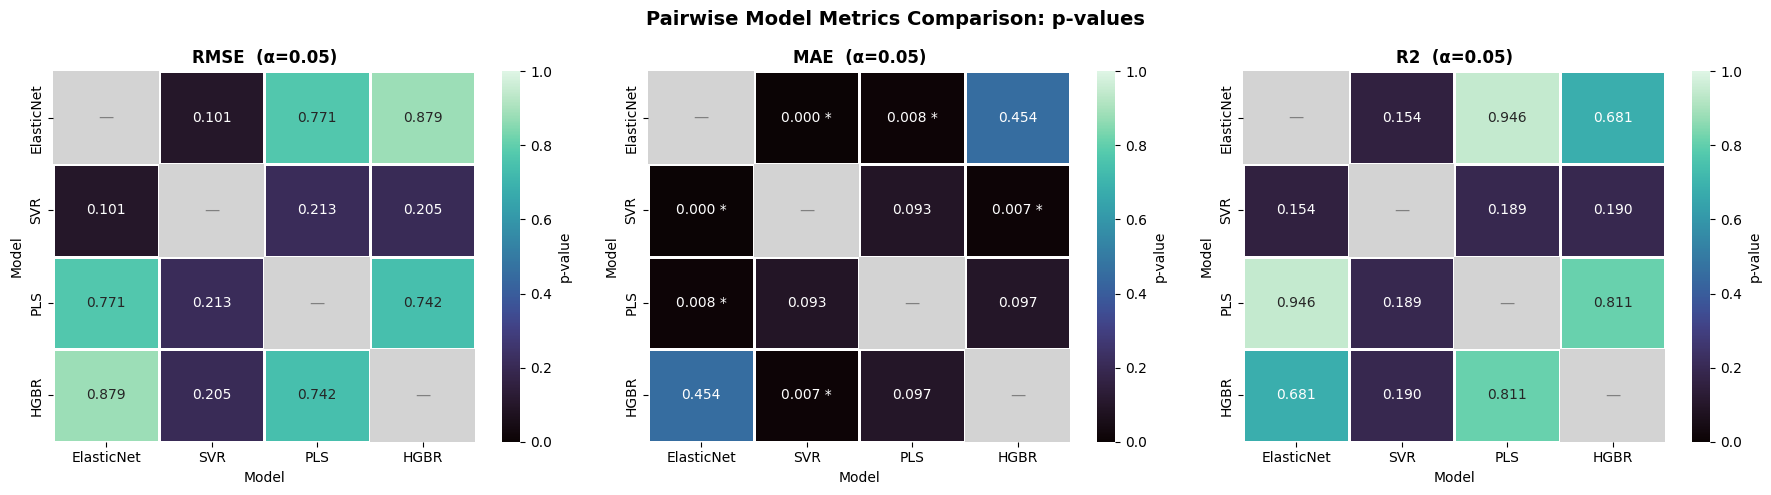

In [ ]:
importlib.reload(model)
results_dict = {
    'ElasticNet': joblib.load(os.path.join(MODEL_DIR, 'en_results_df.pkl')),
    'SVR':        joblib.load(os.path.join(MODEL_DIR, 'svr_results.pkl')),
    'PLS':        joblib.load(os.path.join(MODEL_DIR, 'pls_results.pkl')),
    'HGBR':       joblib.load(os.path.join(MODEL_DIR, 'hgbr_results.pkl')),
}

p_vals = model.pairwise_metric_comparison(results_dict, alpha=0.05)